In [2]:
# MULTIPLE REGRESSION, RIDGE, AND LASSO
# USING GLOBAL GDP DATASET

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

# Load dataset
df = pd.read_csv('/content/global_gdp_inflation_2000_2024.csv')

# Drop missing values
df = df.dropna()

# Convert categorical columns (like Country) into dummy variables
df = pd.get_dummies(df, drop_first=True)

# Select numeric columns
numeric_cols = df.select_dtypes(include=np.number).columns

# Assume first numeric column is GDP (target)
target_column = numeric_cols[0]

X = df.drop(target_column, axis=1)
y = df[target_column]

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Scale features (important for Ridge & Lasso)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# -------------------------------
# 1️⃣ Multiple Linear Regression
# -------------------------------
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)
y_pred_linear = linear_model.predict(X_test)

print("MULTIPLE LINEAR REGRESSION")
print("MSE:", mean_squared_error(y_test, y_pred_linear))
print("R2 Score:", r2_score(y_test, y_pred_linear))
print("--------------------------------------------------")

# -------------------------------
# 2️⃣ Ridge Regression
# -------------------------------
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train, y_train)
y_pred_ridge = ridge_model.predict(X_test)

print("RIDGE REGRESSION")
print("MSE:", mean_squared_error(y_test, y_pred_ridge))
print("R2 Score:", r2_score(y_test, y_pred_ridge))
print("--------------------------------------------------")

# -------------------------------
# 3️⃣ Lasso Regression
# -------------------------------
lasso_model = Lasso(alpha=0.1)
lasso_model.fit(X_train, y_train)
y_pred_lasso = lasso_model.predict(X_test)

print("LASSO REGRESSION")
print("MSE:", mean_squared_error(y_test, y_pred_lasso))
print("R2 Score:", r2_score(y_test, y_pred_lasso))

MULTIPLE LINEAR REGRESSION
MSE: 51.68358714712666
R2 Score: -0.060566281862248994
--------------------------------------------------
RIDGE REGRESSION
MSE: 51.68287933028078
R2 Score: -0.060551757199354794
--------------------------------------------------
LASSO REGRESSION
MSE: 48.198636703682375
R2 Score: 0.010946187343042535


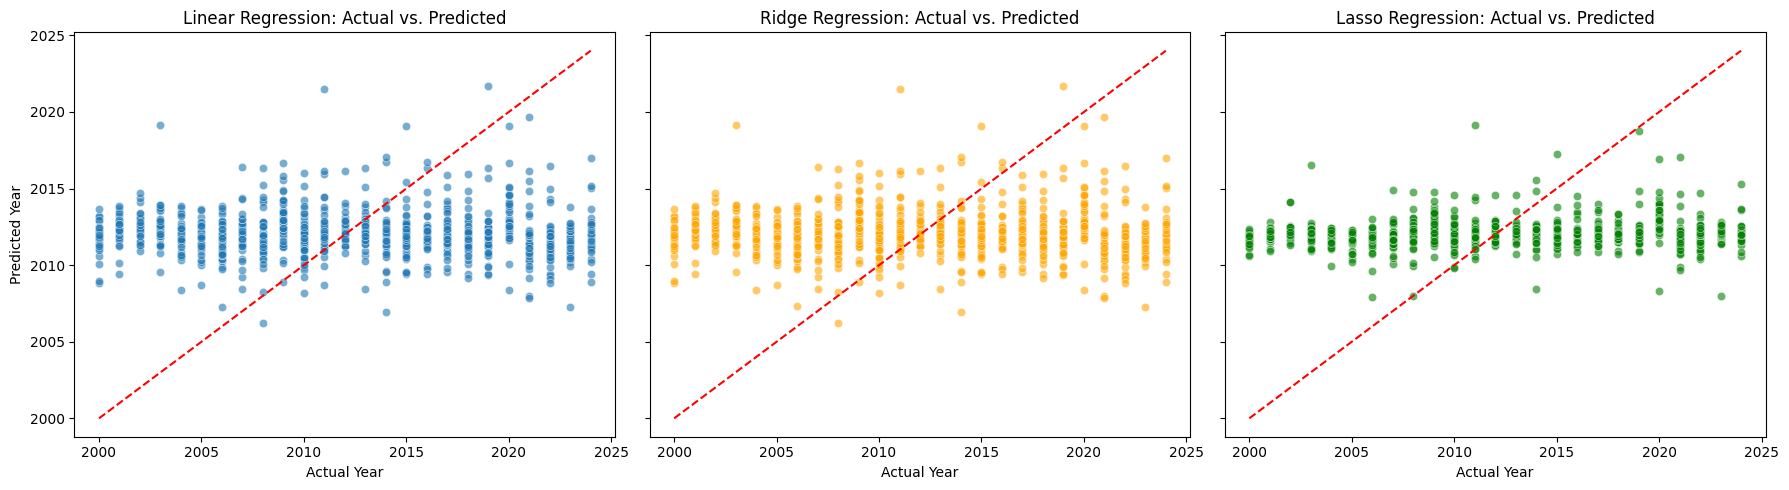

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a figure with subplots for each model
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True, sharey=True)

# Plot for Multiple Linear Regression
sns.scatterplot(x=y_test, y=y_pred_linear, ax=axes[0], alpha=0.6)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
axes[0].set_title('Linear Regression: Actual vs. Predicted')
axes[0].set_xlabel('Actual Year')
axes[0].set_ylabel('Predicted Year')

# Plot for Ridge Regression
sns.scatterplot(x=y_test, y=y_pred_ridge, ax=axes[1], alpha=0.6, color='orange')
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
axes[1].set_title('Ridge Regression: Actual vs. Predicted')
axes[1].set_xlabel('Actual Year')
axes[1].set_ylabel('Predicted Year')

# Plot for Lasso Regression
sns.scatterplot(x=y_test, y=y_pred_lasso, ax=axes[2], alpha=0.6, color='green')
axes[2].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
axes[2].set_title('Lasso Regression: Actual vs. Predicted')
axes[2].set_xlabel('Actual Year')
axes[2].set_ylabel('Predicted Year')

plt.tight_layout()
plt.show()